# 15_charts — nb4-style chart pair for every gallery line (fully offline)

Companion to nb15: for each persisted portfolio line in the gallery register,
the same two charts as nb04 §4 (the equity curve vs a SPY buy-and-hold benchmark,
and the drawdown of both), one pair per line.

Everything is read from local parquet files, without network, DB, or credential access:

- the equity lines from `data/<stem>.parquet` (the nb15 register),
- the SPY benchmark from `data/etf_prices_wide_2013_2026.parquet` (the close panel
  persisted by nb17), rebased to each line's value at its active start.

Caveats, same framing as nb15: **realized simulation equity curves only**, windows
differ per line, the benchmark is raw-close SPY B&H (the same `etf_prices` source
nb04 used). The panel's SPY history ends 2026-05-29, so on the ext2026 lines the
benchmark stops a month before the line does.

## 1. Load the register + the SPY benchmark panel

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA = Path("..") / "data"

# same register as nb15 cell 1: (file stem, short label, is_diagnostic)
LINES = [
    ("static_bh_equity_2016_2026", "Static B&H 16-26", False),
    ("static_bh_equity_2014_2024", "Static B&H 14-24", False),
    ("factor_equity_v1", "Factor v1", False),
    ("factor_equity_v2", "Factor v2", False),
    ("factor_nonpit_diagnostic_equity_v1", "Factor non-PIT v1", True),
    ("factor_equity_ext2026", "Factor ext26", False),
    ("factor_nonpit_diagnostic_equity_ext2026", "Factor non-PIT ext26", True),
    ("baseline_equity_2019_2024", "Baseline 19-24", False),
    ("track_a_equity_2019_2024", "Track A 19-24", False),
    ("track_a_steered_equity_2019_2024", "Track A steered", False),
    ("track_b_equity_2019_2024", "Track B 19-24", False),
    ("baseline_equity_ext2026", "Baseline ext26", False),
    ("track_b_equity_ext2026", "Track B ext26", False),
    ("sjm_crowding_derisk_equity_ext2026", "SJM×crowding de-risk ext26", False),
]

DIAG_TAG = "DIAGNOSTIC CONTROL — never deployable"


def active_value(value: pd.Series) -> pd.Series:
    """Trim to the active span — same convention as nb15 / scripts/build_tear_sheet.py."""
    moving = value[value.ne(value.iloc[0])]
    if moving.empty:
        return value
    first_move = moving.index.min()
    prior = value.index[value.index < first_move]
    start = prior.max() if len(prior) else first_move
    return value.loc[start:]


loaded: dict[str, tuple[str, bool, pd.Series]] = {}
for stem, label, diag in LINES:
    path = DATA / f"{stem}.parquet"
    if not path.exists():
        print(f"SKIPPED (not present locally): {path.name}")
        continue
    loaded[stem] = (label, diag, active_value(pd.read_parquet(path)["value"]))
print(f"{len(loaded)}/{len(LINES)} lines loaded")

spy_px = pd.read_parquet(DATA / "etf_prices_wide_2013_2026.parquet")["SPY"].dropna()
print(f"SPY benchmark: {spy_px.index[0].date()} .. {spy_px.index[-1].date()}")


def spy_bench(value: pd.Series) -> pd.Series:
    """SPY B&H over the line's window, rebased to the line's starting value.

    Reindexed onto the line's (union) calendar with a 5-day ffill cap — the same
    listing-gap convention as nb17; beyond the panel's last SPY date the benchmark
    simply ends (NaN) instead of flatlining.
    """
    s = spy_px.reindex(value.index).ffill(limit=5).dropna()
    return s / s.iloc[0] * value.loc[s.index[0]]

14/14 lines loaded
SPY benchmark: 2013-01-02 .. 2026-05-28


## 2. Equity curve & drawdown — one nb4-style pair per line

Chart pair per line, exactly as nb04 §4: `value` vs `SPY B&H` equity, then both
drawdowns ($10{,}000$ initial, each line's own window).

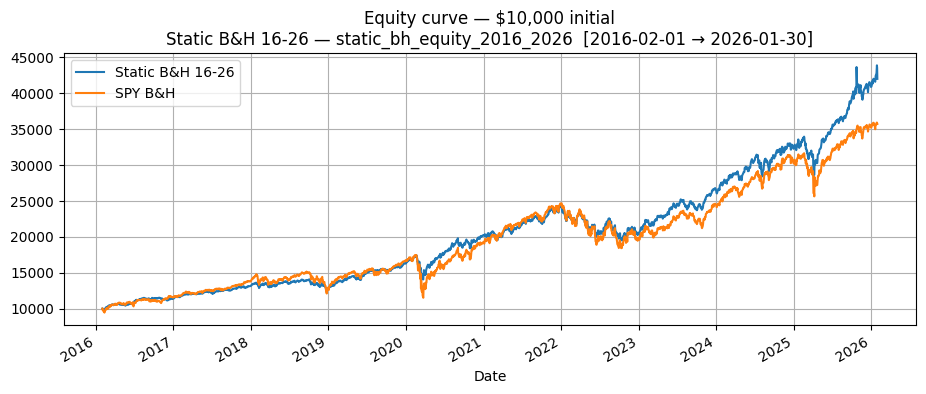

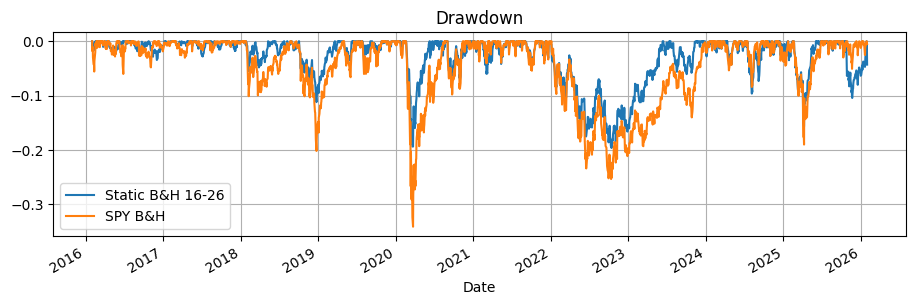

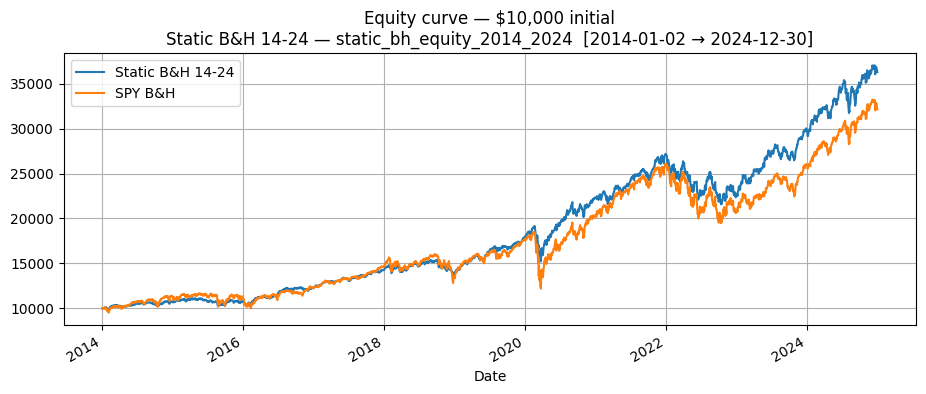

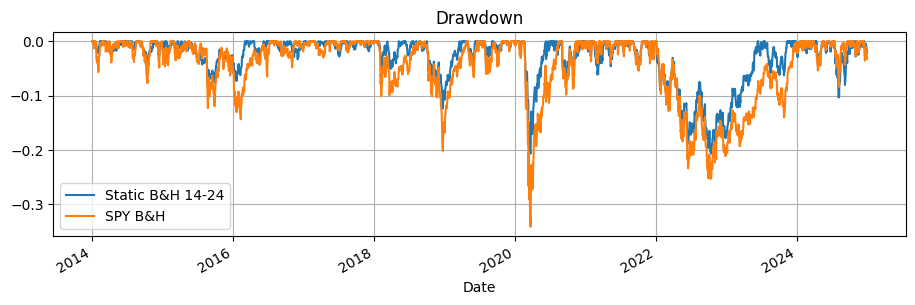

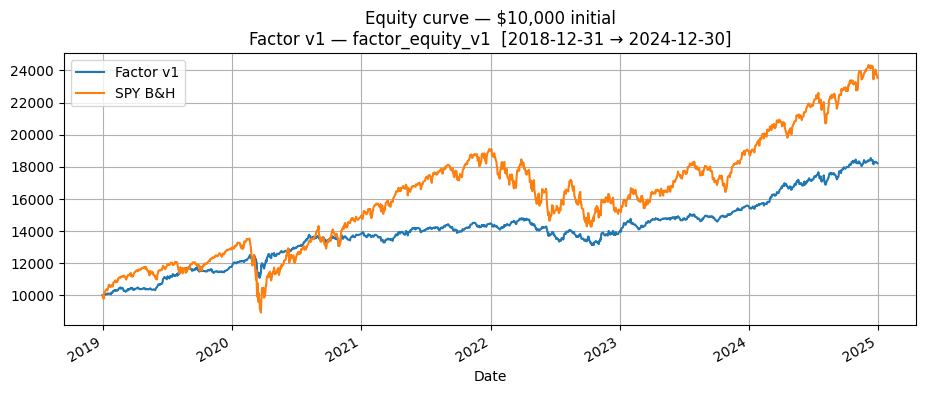

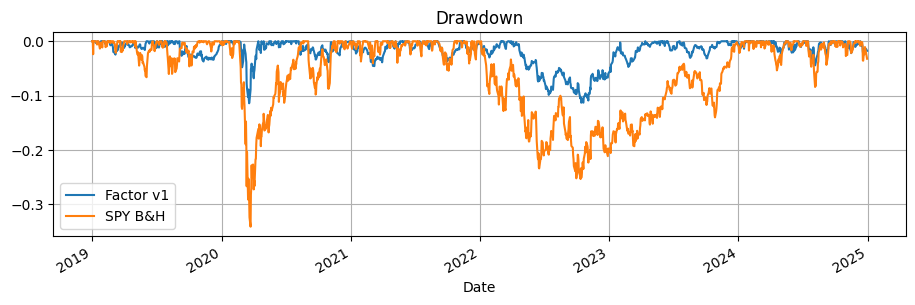

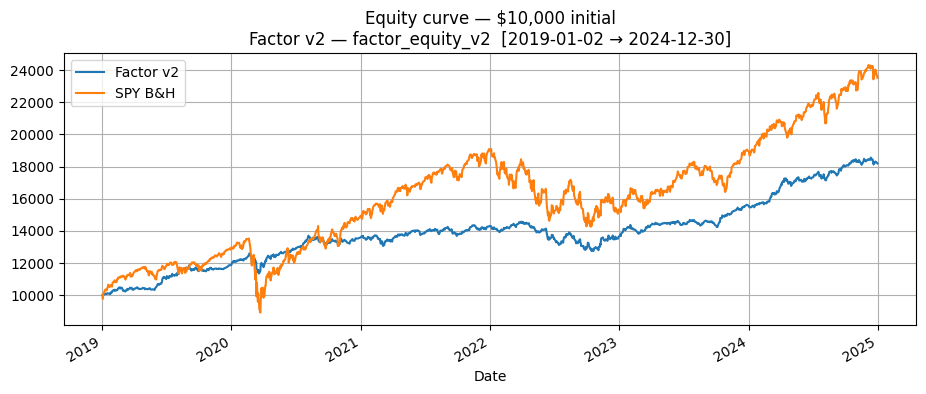

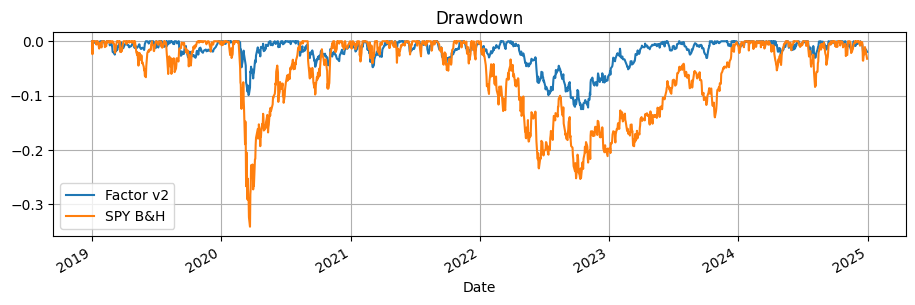

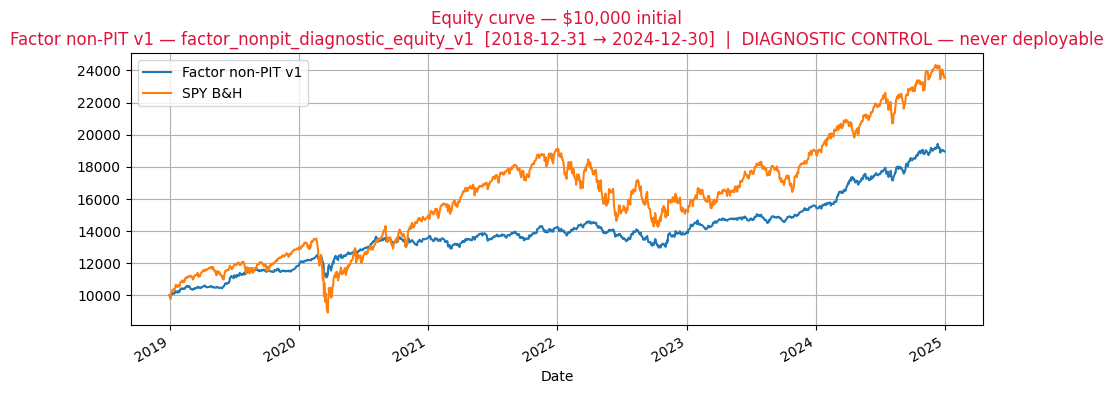

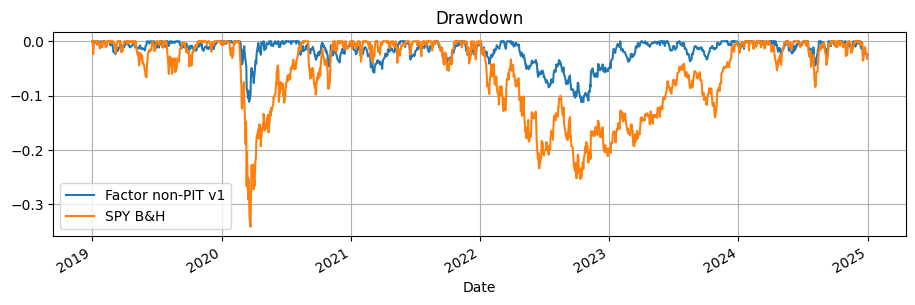

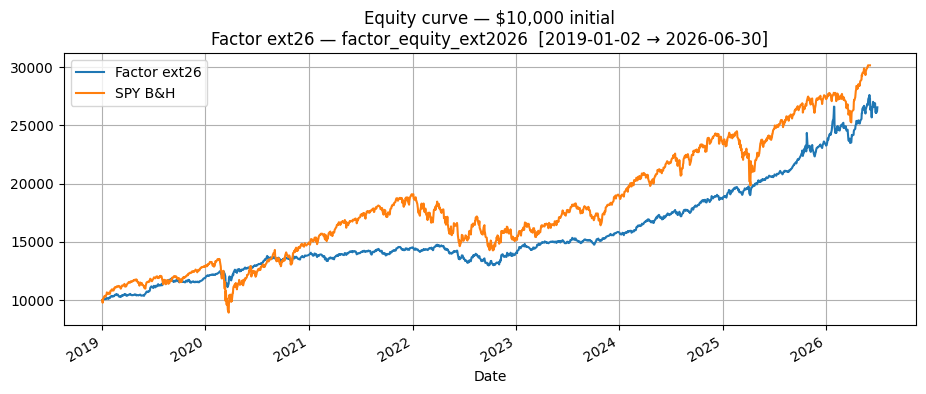

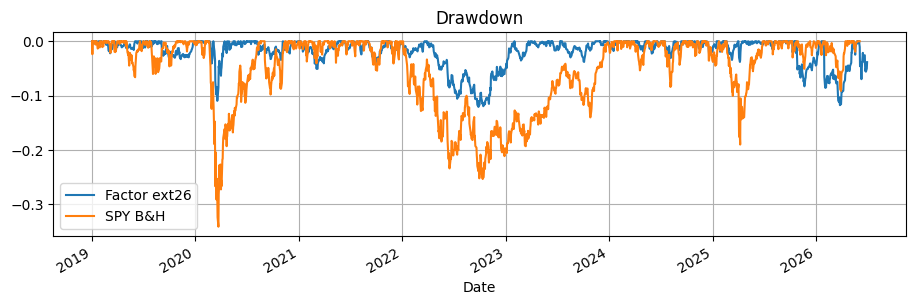

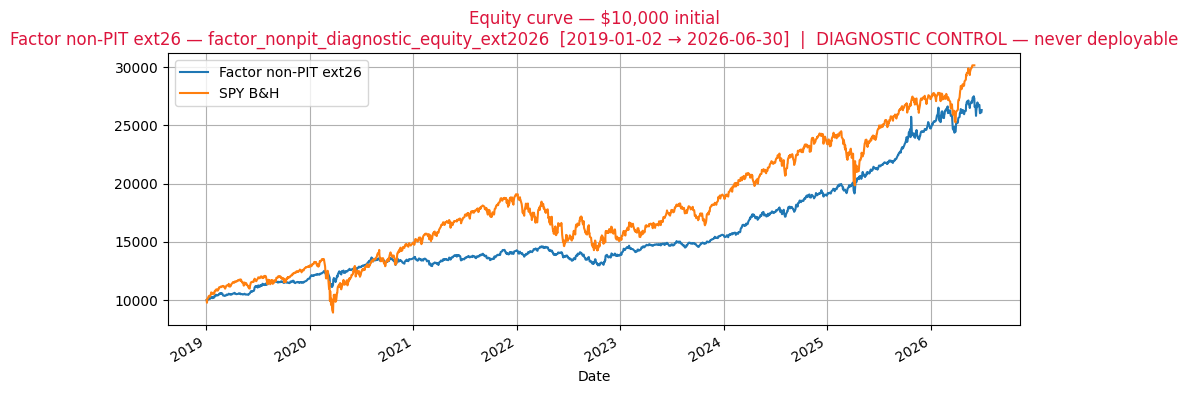

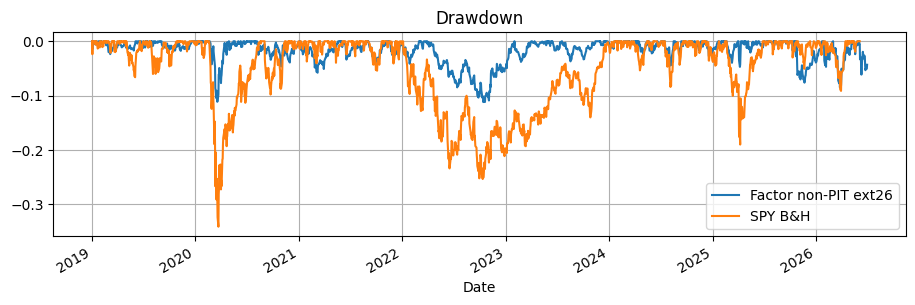

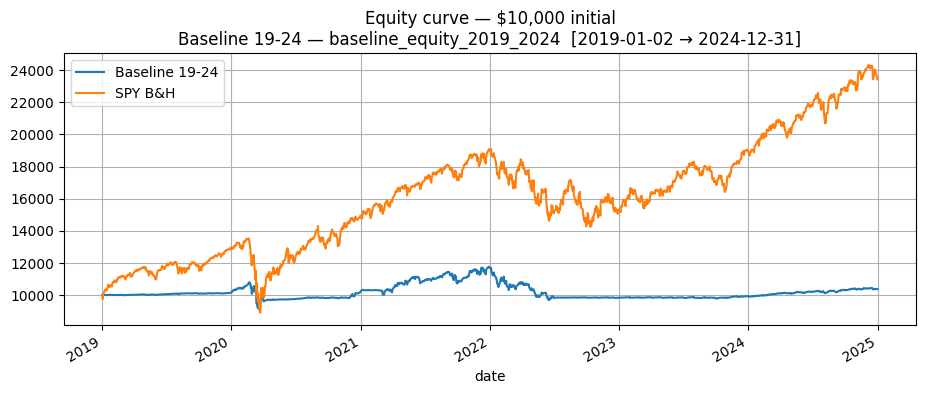

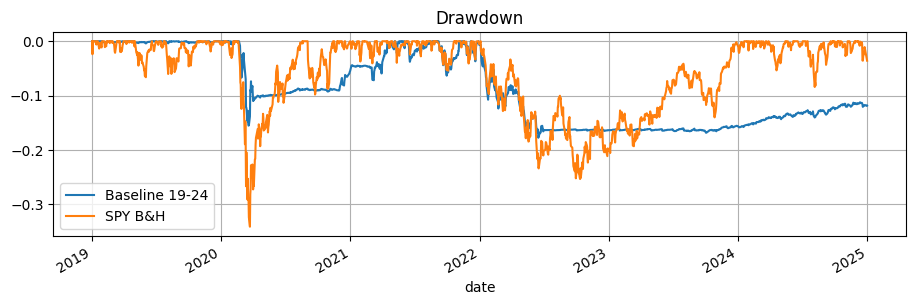

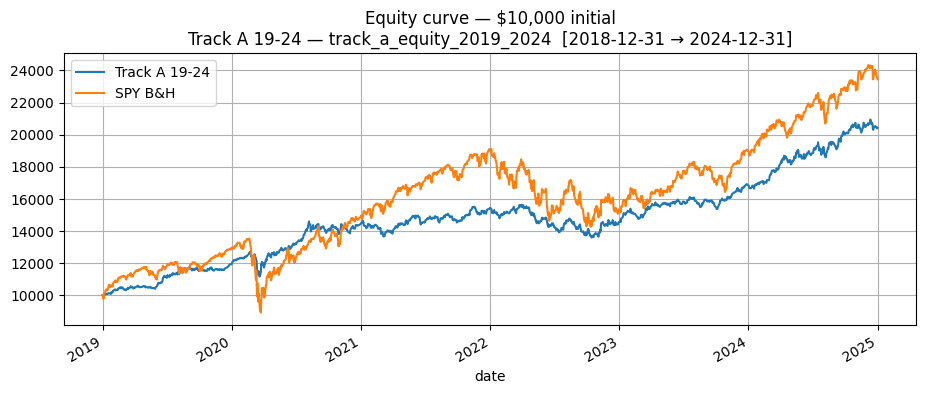

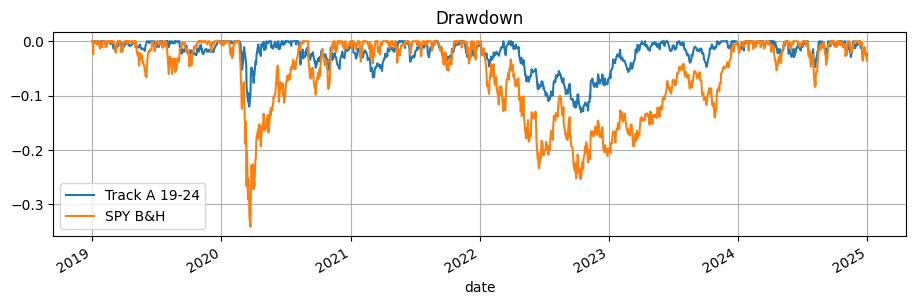

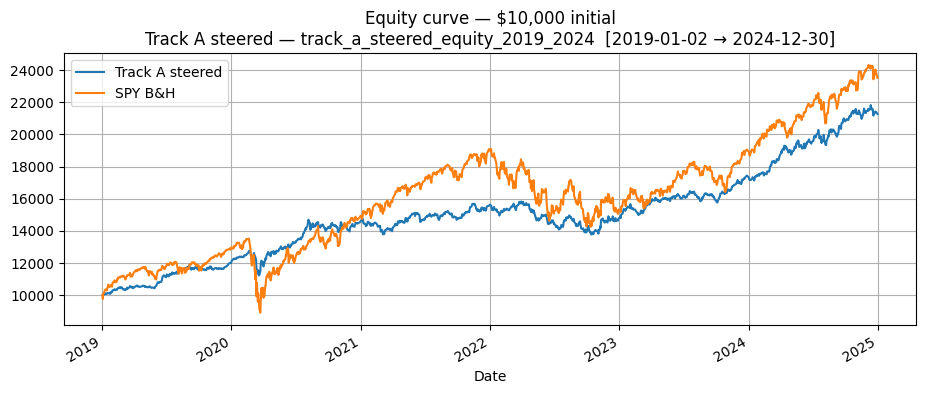

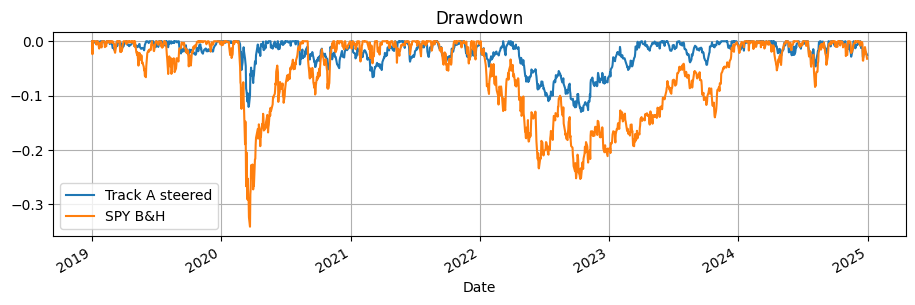

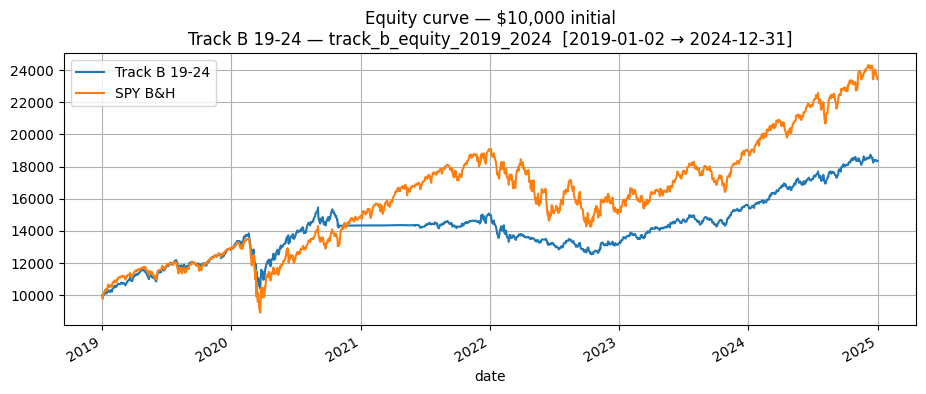

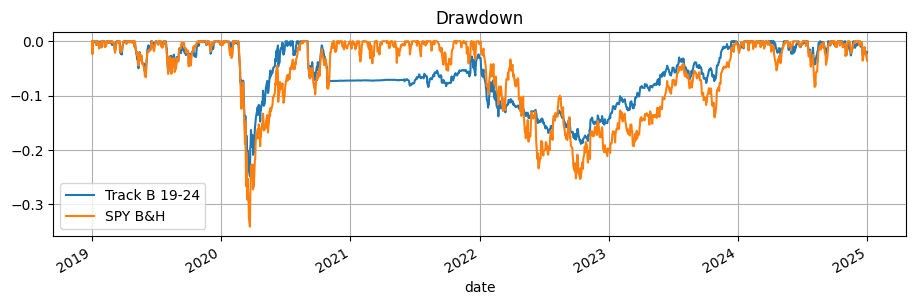

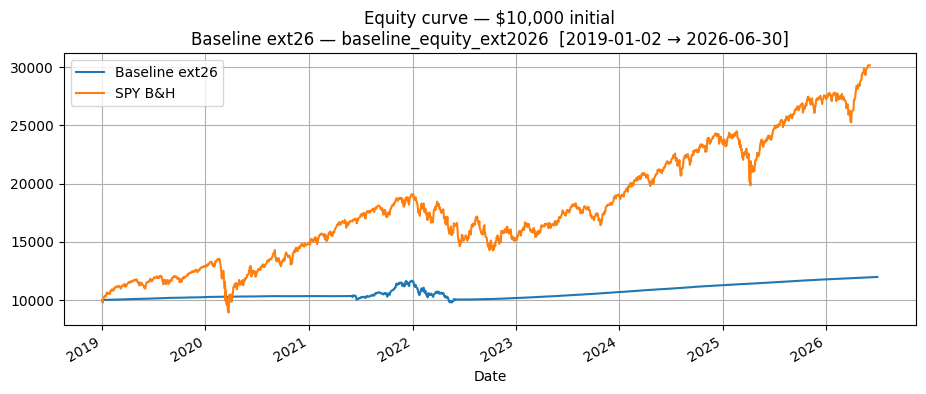

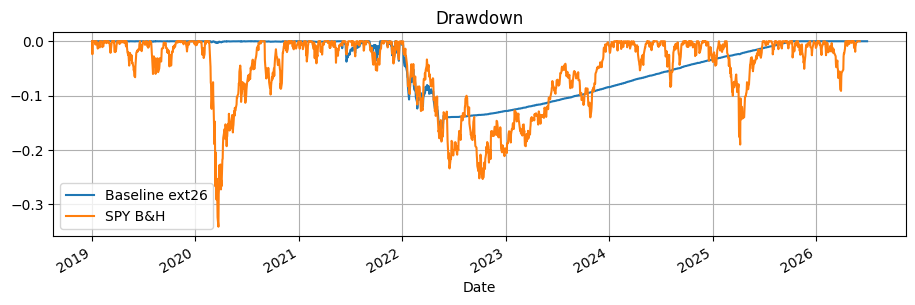

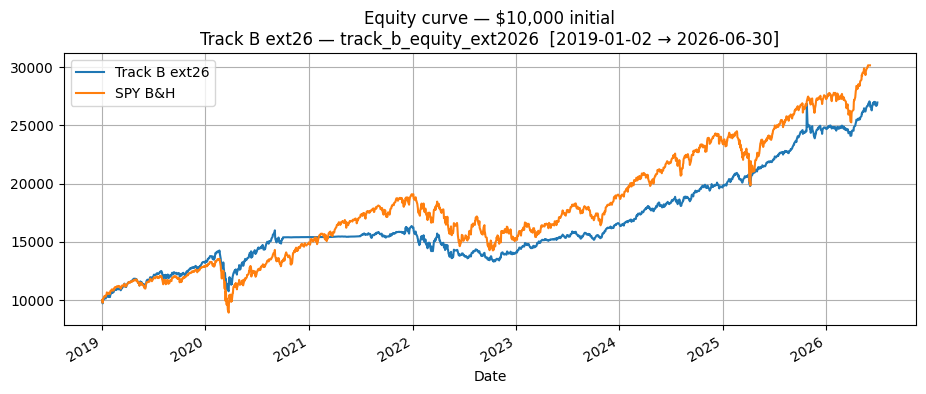

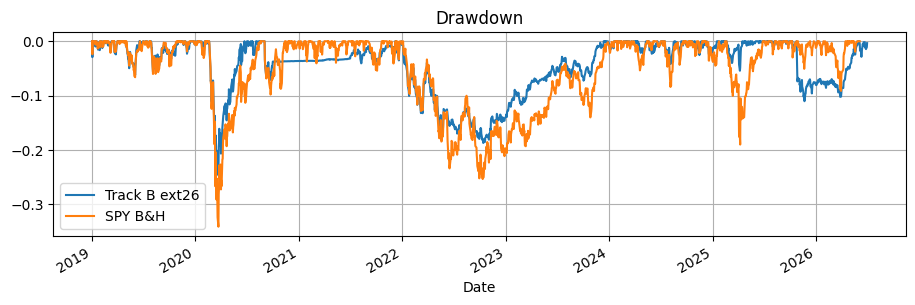

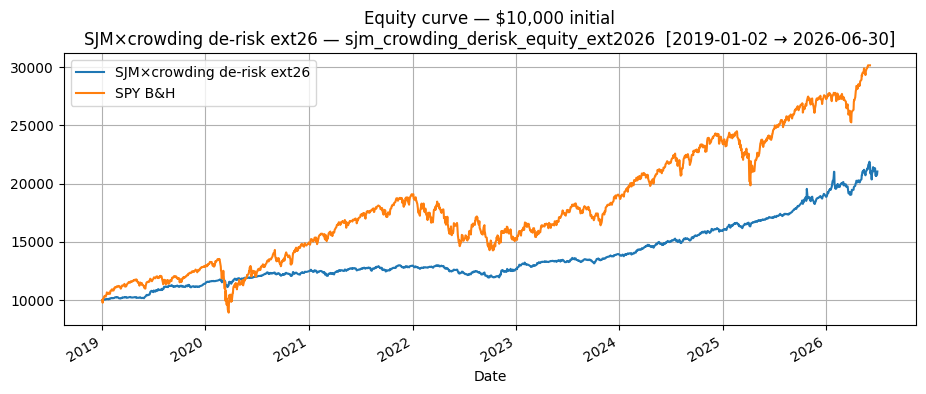

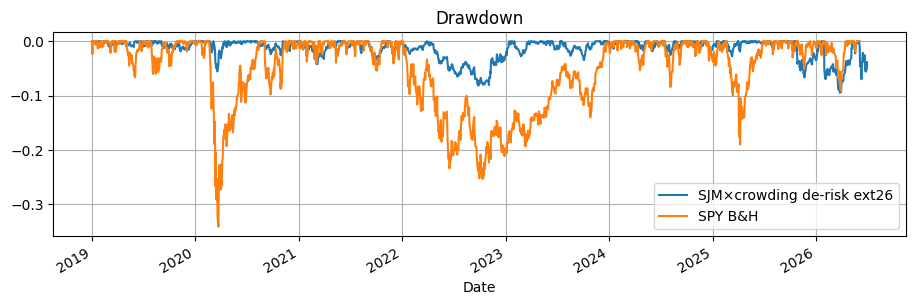

In [2]:
for stem, (label, diag, value) in loaded.items():
    bench = spy_bench(value)
    title = f"{label} — {stem}  [{value.index.min():%Y-%m-%d} → {value.index.max():%Y-%m-%d}]"
    if diag:
        title += f"  |  {DIAG_TAG}"

    equity = pd.DataFrame({label: value, "SPY B&H": bench})
    ax = equity.plot(figsize=(11, 4), grid=True,
                     title=f"Equity curve — $10,000 initial\n{title}")
    ax.title.set_color("crimson" if diag else "black")
    plt.show()

    drawdowns = pd.DataFrame({label: value / value.cummax() - 1,
                              "SPY B&H": bench / bench.cummax() - 1})
    drawdowns.plot(figsize=(11, 3), grid=True, title="Drawdown")
    plt.show()

---

Realized simulation curves only — no forecast-accuracy claims. Per-run provenance:
`workbook/SIMULATIONS.md`; the single-line gallery (no benchmark overlay) is
nb15; the benchmark construction mirrors nb04 (SPY buy-and-hold, same price source).